# 03 — Análise Exploratória de Dados (EDA)

**Objetivo:** Investigar padrões, tendências e insights nos dados de preços de combustíveis.

**Análises:**
1. Evolução histórica dos preços por combustível
2. Comparação entre estados (mais caro vs mais barato)
3. Análise por bandeira (Shell, Ipiranga, BR, branca)
4. Sazonalidade (preço varia por mês?)
5. Impacto de eventos (COVID-19, Guerra Ucrânia, política Petrobras)
6. Recorte regional: Presidente Prudente vs SP vs Brasil

**Ferramentas:** Matplotlib, Seaborn, Plotly

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src.eda import (
    plot_evolucao_preco, plot_comparativo_estados, plot_bandeiras,
    plot_sazonalidade, plot_pp_vs_sp_vs_brasil, plot_correlacao_heatmap
)
from src.utils import DATA_PROCESSED, construir_coluna_data

%matplotlib inline

In [2]:
import duckdb

PARQUET = str(DATA_PROCESSED / 'combustiveis_brasil.parquet')

with duckdb.connect() as con:
    stats = con.execute(f"""
        SELECT COUNT(*) as n,
               MIN(data_coleta) as inicio,
               MAX(data_coleta) as fim
        FROM read_parquet('{PARQUET}')
    """).fetchdf().iloc[0]

    df_corr = con.execute(f"""
        SELECT ano, mes,
               AVG(valor_venda)     AS valor_venda,
               AVG(dolar_venda)     AS dolar_venda,
               AVG(preco_brent_usd) AS preco_brent_usd
        FROM read_parquet('{PARQUET}')
        GROUP BY ano, mes
        ORDER BY ano, mes
    """).fetchdf()

print(f"Dataset principal: {int(stats['n']):,} registros")
print(f"Período: {stats['inicio']} a {stats['fim']}")
print(f"df_corr (mensal para correlação): {len(df_corr)} linhas")

df_mensal   = pd.read_parquet(DATA_PROCESSED / 'agg_mensal_nacional.parquet')
df_estado   = pd.read_parquet(DATA_PROCESSED / 'agg_mensal_estado_produto.parquet')
df_bandeira = pd.read_parquet(DATA_PROCESSED / 'agg_por_bandeira.parquet')

print(f"\nDólar disponível: {df_corr['dolar_venda'].notna().sum():,} meses")
print(f"Brent disponível: {df_corr['preco_brent_usd'].notna().sum():,} meses")

Dataset principal: 20,484,968 registros
Período: 2004-05-10 00:00:00 a 2025-12-31 00:00:00
df_corr (mensal para correlação): 220 linhas

Dólar disponível: 220 meses
Brent disponível: 220 meses


## 3.1 — Evolução Histórica dos Preços

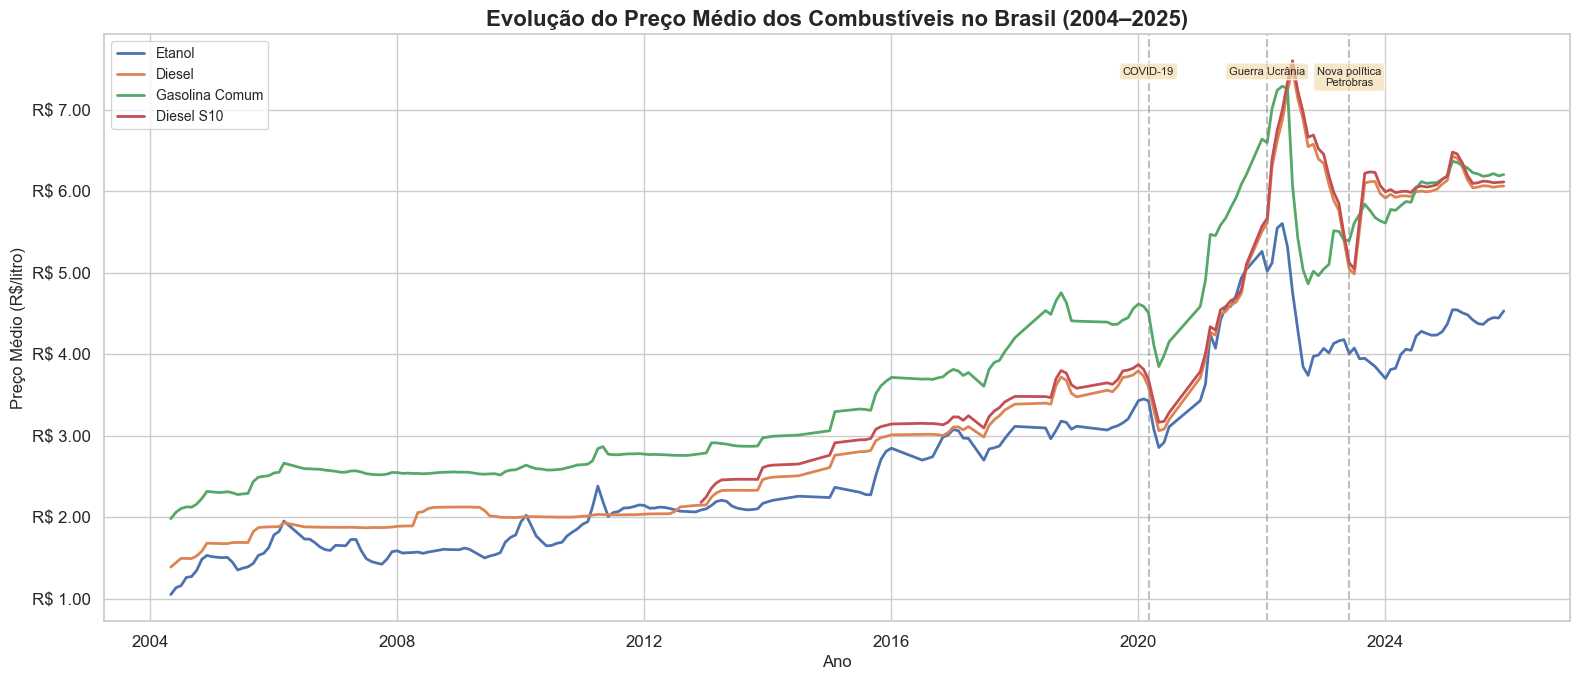

In [3]:
fig = plot_evolucao_preco(
    df_mensal,
    produtos=['Gasolina Comum', 'Etanol', 'Diesel', 'Diesel S10'],
    titulo='Evolução do Preço Médio dos Combustíveis no Brasil (2004–2025)'
)
plt.savefig('../data/processed/fig_evolucao_precos.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2 — Comparação entre Estados

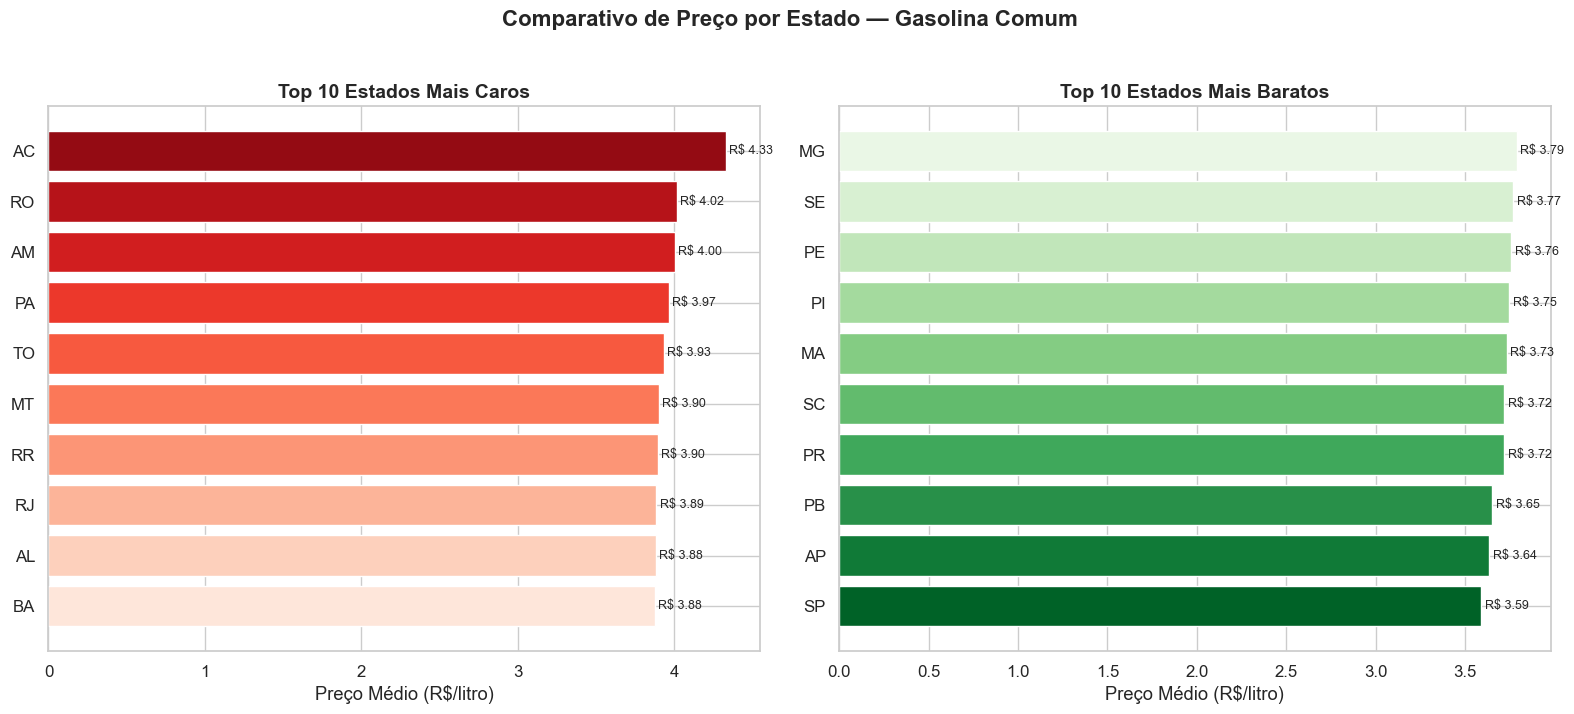

In [4]:
fig = plot_comparativo_estados(df_estado, produto='Gasolina Comum', top_n=10)
plt.savefig('../data/processed/fig_comparativo_estados.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
media_estado = (
    df_estado.groupby('estado_sigla')['preco_medio']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
media_estado.columns = ['Estado', 'Preço Médio (R$/L)']

fig_ranking = px.bar(
    media_estado,
    x='Preço Médio (R$/L)',
    y='Estado',
    orientation='h',
    color='Preço Médio (R$/L)',
    color_continuous_scale='RdYlGn_r',
    title='Preço Médio da Gasolina por Estado (Ranking)',
    text='Preço Médio (R$/L)',
)
fig_ranking.update_traces(texttemplate='R$ %{text:.2f}', textposition='outside')
fig_ranking.update_layout(template='plotly_white', height=700, showlegend=False)
fig_ranking.show()

## 3.3 — Análise por Bandeira

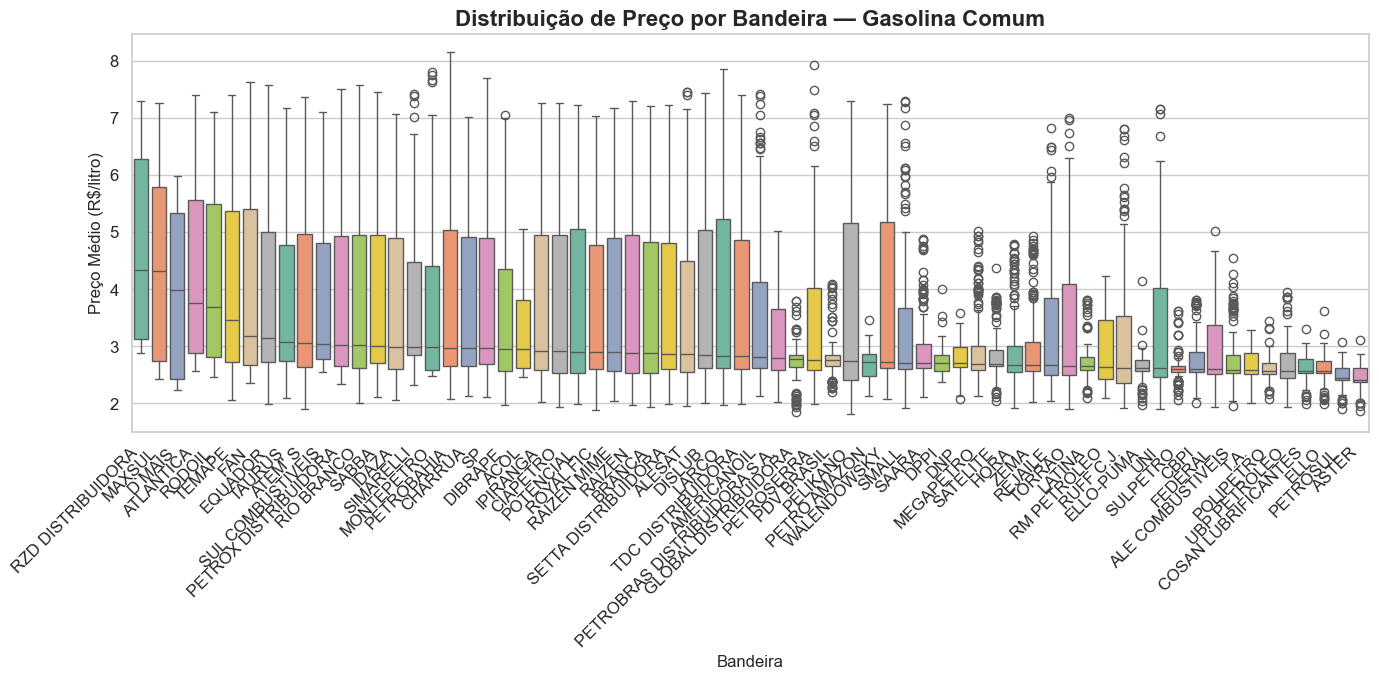

In [6]:
fig = plot_bandeiras(df_bandeira, produto='Gasolina Comum')
plt.savefig('../data/processed/fig_bandeiras.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 — Sazonalidade

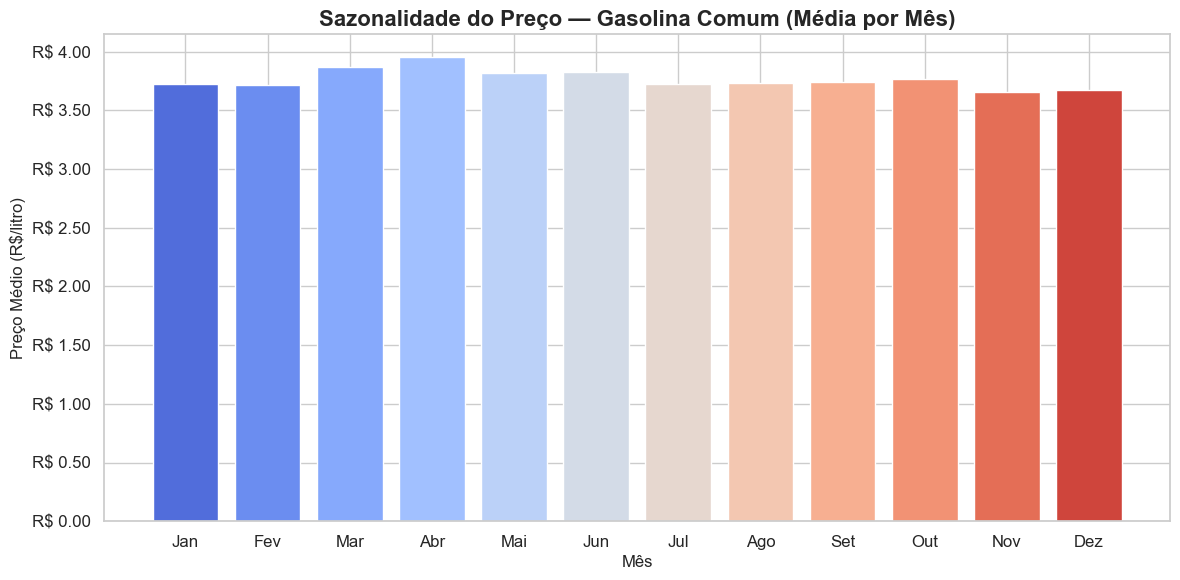

In [7]:
fig = plot_sazonalidade(df_mensal, produto='Gasolina Comum')
plt.savefig('../data/processed/fig_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 — Impacto de Eventos

Análise do impacto de eventos marcantes nos preços:
- **COVID-19 (Março 2020):** Queda na demanda → queda de preços
- **Guerra Ucrânia (Fev 2022):** Alta do petróleo → aumento de preços
- **Nova política Petrobras (2023):** Mudança na política de preços

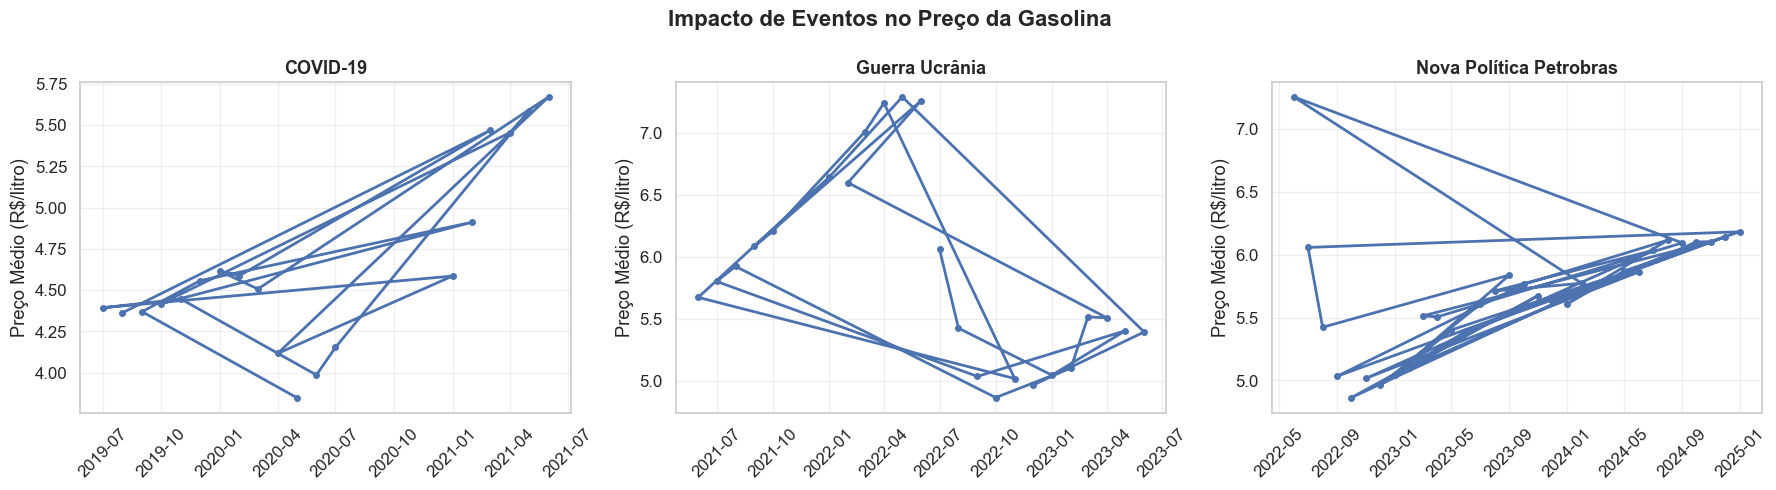

In [8]:
gasolina_mensal = df_mensal[df_mensal['produto_padronizado'] == 'Gasolina Comum'].copy()
gasolina_mensal['data'] = construir_coluna_data(gasolina_mensal)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

eventos = [
    ('COVID-19', '2019-06', '2021-06'),
    ('Guerra Ucrânia', '2021-06', '2023-06'),
    ('Nova Política Petrobras', '2022-06', '2025-01'),
]

for ax, (titulo, inicio, fim) in zip(axes, eventos):
    mask = (gasolina_mensal['data'] >= inicio) & (gasolina_mensal['data'] <= fim)
    subset = gasolina_mensal[mask]
    ax.plot(subset['data'], subset['preco_medio'], marker='o', linewidth=2, markersize=4)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_ylabel('Preço Médio (R$/litro)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle('Impacto de Eventos no Preço da Gasolina', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_impacto_eventos.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 — Presidente Prudente vs SP vs Brasil

In [9]:
try:
    import duckdb
    path = str(DATA_PROCESSED / 'combustiveis_brasil.parquet')
    with duckdb.connect() as con:
        df_pp = con.execute(f"""
            SELECT ano, mes, produto_padronizado,
                AVG(CASE WHEN municipio LIKE '%PRESIDENTE PRUDENTE%' THEN valor_venda END) as preco_pp,
                AVG(CASE WHEN estado_sigla = 'SP' THEN valor_venda END) as preco_sp,
                AVG(valor_venda) as preco_brasil
            FROM read_parquet('{path}')
            GROUP BY ano, mes, produto_padronizado
            ORDER BY ano, mes
        """).fetchdf()

    fig_pp = plot_pp_vs_sp_vs_brasil(df_pp, produto='Gasolina Comum')
    fig_pp.show()
except Exception as e:
    print(f"Erro ao gerar gráfico PP: {e}")

## 3.7 — Correlação: Combustível vs Dólar vs Brent

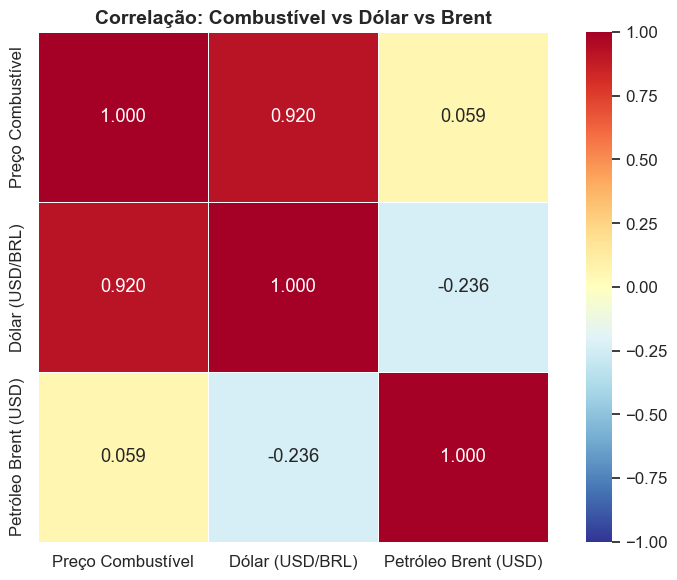

In [10]:
fig = plot_correlacao_heatmap(df_corr)
plt.savefig('../data/processed/fig_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

---
**Próximo passo:** [04_modelagem_ml.ipynb](04_modelagem_ml.ipynb) — Modelos de Machine Learning